# Exploratory Data Analysis DIAObject & Object

**Goals**
1) Summarize variability over time
2) Identify candidate variable stars
3) Enable efficient filtering and prioritization
4) Support feature engineering and PCA for classification 
5) Enable cross-band behavior analysis

**Core Columns**

**DiaObject**

PSFluxChi2, PSFluxSigma, PSFluxStetsonJ, PSFluxMax, PSFluxMin, PSFluxMAD, PSFluxSkew, PSFluxLinearSlope, PSFluxNdata

**Object**

psfFlux, psfFluxErr, cModelFlux, extendedness, pixelFlags_bad, inputCount, calib_photometry_used, apFlux_flag, cModel_flag

**Summary Tables**

**DiaObject**

| Metric                      | Description                                              |
|-----------------------------|----------------------------------------------------------|
| ```Chi²```, ```Stetson J``` | Variability consistency                                  |
| ```Sigma```, ```MAD```      | Spread and robustness                                    |
| ```Skew```                  | Asymmetry of variability                                 |
| ```Max/Min/Range```         | Amplitude indicators                                     |
| ```Linear Slope```          | Temporal trends (e.g., sawtooth patterns)                |
| ```Ndata```                 | Confidence indicator for above statistics                |

**Object**

| Metric / Flag            | Description                                              |
|--------------------------|----------------------------------------------------------|
| `psfFlux`, `psfFluxErr`  | Photometric brightness and uncertainty (used for magnitudes and S/N filtering) |
| `cModelFlux`             | Model-based flux fit for extended sources (helps identify galaxies) |
| `extendedness`           | Binary star/galaxy separator: 0 = point source, 1 = extended |
| `pixelFlags_bad`         | Flag for bad pixels impacting flux measurements          |
| `inputCount`             | Number of exposures contributing to the flux measurement |
| `calib_photometry_used`  | Indicator of whether photometric calibration was applied |
| `apFlux_flag`, `cModel_flag` | Flags for aperture/model photometry reliability         |

**Tasks - Key Visualizations**
1) Chi² vs Flux Std Dev (per band)

In [2]:
# libraries, imports, etc
import numpy
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from matplotlib import colormaps
import seaborn as sns

print('numpy version: ', numpy.__version__)
print('matplotlib version: ', matplotlib.__version__)

numpy version:  2.2.6
matplotlib version:  3.10.3


In [3]:
# TAP Service 
from lsst.rsp import get_tap_service, retrieve_query

service = get_tap_service("tap")
assert service is not None

In [4]:
# DiaObject g-band
diaobjectG_query = """
SELECT TOP 100000
    decl, diaObjectId, gPSFluxChi2, gPSFluxErrMean, gPSFluxLinearSlope,
    gPSFluxMAD, gPSFluxMax, gPSFluxMean, gPSFluxMeanErr, gPSFluxMin, gPSFluxNdata,
    gPSFluxSigma, gPSFluxStetsonJ, gPSFluxSkew
FROM dp02_dc2_catalogs.DiaObject
"""
diaobjectG_df = service.search(diaobjectG_query).to_table().to_pandas()

# DiaObject r-band
diaobjectR_query = """
SELECT TOP 100000
    decl, diaObjectId, rPSFluxChi2, rPSFluxErrMean, rPSFluxLinearSlope,
    rPSFluxMAD, rPSFluxMax, rPSFluxMean, rPSFluxMeanErr, rPSFluxMin, rPSFluxNData,
    rPSFluxSigma, rPSFluxStetsonJ, rPSFluxSkew
FROM dp02_dc2_catalogs.DiaObject
"""
diaobjectR_df = service.search(diaobjectR_query).to_table().to_pandas()

# DiaObject i-band
diaobjectI_query = """
SELECT TOP 100000
    decl, diaObjectId, iPSFluxChi2, iPSFluxErrMean, iPSFluxLinearSlope,
    iPSFluxMAD, iPSFluxMax, iPSFluxMean, iPSFluxMeanErr, iPSFluxMin, iPSFluxNData,
    iPSFluxSigma, iPSFluxStetsonJ, iPSFluxSkew
FROM dp02_dc2_catalogs.DiaObject
"""
diaobjectI_df = service.search(diaobjectI_query).to_table().to_pandas()

# Object g-band
objectG_query = """
SELECT TOP 100000
    objectId, coord_ra, coord_dec, footprintArea, g_apFlux_flag, 
    g_apFlux_flag_apertureTruncated, g_bdChi2, g_bdFluxDErr, 
    g_calib_astrometry_used, g_calib_photometry_used, g_calibFlux_flag, 
    g_calibFlux_flag_apertureTruncated, g_cModel_flag, g_cModelFlux, g_decl, 
    g_extendedness, g_extendedness_flag, g_i_flag, g_inputCount, g_pixelFlags_bad, 
    g_psfFlux, g_psfFlux_flag, g_psfFluxErr, g_ra

FROM dp02_dc2_catalogs.Object
"""
objectG_df = service.search(objectG_query).to_table().to_pandas()

# Object r-band
objectR_query = """
SELECT TOP 100000
    objectId, coord_ra, coord_dec, footprintArea, r_apFlux_flag, 
    r_apFlux_flag_apertureTruncated, r_bdChi2, r_bdFluxDErr, 
    r_calib_astrometry_used, r_calib_photometry_used, r_calibFlux_flag, 
    r_calibFlux_flag_apertureTruncated, r_cModel_flag, r_cModelFlux, r_decl, 
    r_extendedness, r_extendedness_flag, r_i_flag, r_inputCount, r_pixelFlags_bad, 
    r_psfFlux, r_psfFlux_flag, r_psfFluxErr, r_ra

FROM dp02_dc2_catalogs.Object
"""
objectR_df = service.search(objectR_query).to_table().to_pandas()

# Object i-band 
objectI_query = """
SELECT TOP 100000
    objectId, coord_ra, coord_dec, footprintArea, i_apFlux_flag, 
    i_apFlux_flag_apertureTruncated, i_bdChi2, i_bdFluxDErr, 
    i_calib_astrometry_used, i_calib_photometry_used, i_calibFlux_flag, 
    i_calibFlux_flag_apertureTruncated, i_cModel_flag, i_cModelFlux, i_decl, 
    i_extendedness, i_extendedness_flag, i_i_flag, i_inputCount, i_pixelFlags_bad, 
    i_psfFlux, i_psfFlux_flag, i_psfFluxErr, i_ra

FROM dp02_dc2_catalogs.Object
"""
objectI_df = service.search(objectI_query).to_table().to_pandas()

In [8]:
# DiaObject (g, r, and i bands)
diaobjectG_df.to_csv("diaobjectG_sample_EDA.csv", index=False)
diaobjectR_df.to_csv("diaobjectR_sample_EDA.csv", index=False)
diaobjectI_df.to_csv("diaobjectI_sample_EDA.csv", index=False)

diaobjectGdf = pd.read_csv("diaobjectG_sample_EDA.csv").dropna()
diaobjectRdf = pd.read_csv("diaobjectR_sample_EDA.csv").dropna()
diaobjectIdf = pd.read_csv("diaobjectI_sample_EDA.csv").dropna()

diaobjectGdf.to_csv("diaobjectG_sample_EDA_cleaned.csv", index = False)
diaobjectRdf.to_csv("diaobjectR_sample_EDA_cleaned.csv", index = False)
diaobjectIdf.to_csv("diaobjectI_sample_EDA_cleaned.csv", index = False)

# Object (g, r, and i bands)
objectG_df.to_csv("objectG_sample_EDA.csv", index=False)
objectR_df.to_csv("objectR_sample_EDA.csv", index=False)
objectI_df.to_csv("objectI_sample_EDA.csv", index=False)

objectGdf = pd.read_csv("objectG_sample_EDA.csv").dropna()
objectRdf = pd.read_csv("objectR_sample_EDA.csv").dropna()
objectIdf = pd.read_csv("objectI_sample_EDA.csv").dropna()

objectGdf.to_csv("objectG_sample_EDA_cleaned.csv", index = False)
objectRdf.to_csv("objectR_sample_EDA_cleaned.csv", index = False)
objectIdf.to_csv("objectI_sample_EDA_cleaned.csv", index = False)

# Object (g, r, i bands) 
objectGdf = objectGdf[
    (~objectGdf['g_psfFlux_flag']) &
    (objectGdf['g_psfFlux'] > 0)
]

objectRdf = objectRdf[
    (~objectRdf['r_psfFlux_flag']) &
    (objectRdf['r_psfFlux'] > 0)
]

objectIdf = objectIdf[
    (~objectIdf['i_psfFlux_flag']) &
    (objectIdf['i_psfFlux'] > 0)
]
objectGdf.to_csv("objectG_sample_relevant_flagcleaned.csv", index=False)
objectRdf.to_csv("objectR_sample_relevant_flagcleaned.csv", index=False)
objectIdf.to_csv("objectI_sample_relevant_flagcleaned.csv", index=False)

# DiaObject

In [92]:
# Merging all for cross-band analysis

# renamed columns to avoid name clashing and also kept band identifiers for clarity
g_df = diaobjectG_df.rename(columns=lambda x: f"g_{x}" if x not in ["diaObjectId", "decl"] else x)
r_df = diaobjectR_df.rename(columns=lambda x: f"r_{x}" if x not in ["diaObjectId", "decl"] else x)
i_df = diaobjectI_df.rename(columns=lambda x: f"i_{x}" if x not in ["diaObjectId", "decl"] else x)

# Merge on diaObjectId
merged_df = g_df.merge(r_df, on="diaObjectId", suffixes=("", "_r"))
merged_df = merged_df.merge(i_df, on="diaObjectId", suffixes=("", "_i"))

# derived features (colors, amplitudes)
merged_df["g_r_color"] = merged_df["g_gPSFluxMean"] - merged_df["r_rPSFluxMean"]
merged_df["r_i_color"] = merged_df["r_rPSFluxMean"] - merged_df["i_iPSFluxMean"]

merged_df["g_amplitude"] = merged_df["g_gPSFluxMax"] - merged_df["g_gPSFluxMin"]
merged_df["r_amplitude"] = merged_df["r_rPSFluxMax"] - merged_df["r_rPSFluxMin"]
merged_df["i_amplitude"] = merged_df["i_iPSFluxMax"] - merged_df["i_iPSFluxMin"]

diaobject_all = merged_df
# print(diaobject_all)

# Amplitude = Max - Min (per band)
diaobjectG_df["gAmplitude"] = diaobjectG_df["gPSFluxMax"] - diaobjectG_df["gPSFluxMin"]
diaobjectR_df["rAmplitude"] = diaobjectR_df["rPSFluxMax"] - diaobjectR_df["rPSFluxMin"]
diaobjectI_df["iAmplitude"] = diaobjectI_df["iPSFluxMax"] - diaobjectI_df["iPSFluxMin"]

# Colors: g - r, r - i
diaobject_all["g_r_color"] = diaobject_all["g_gPSFluxMean"] - diaobject_all["r_rPSFluxMean"]
diaobject_all["r_i_color"] = diaobject_all["r_rPSFluxMean"] - diaobject_all["i_iPSFluxMean"]

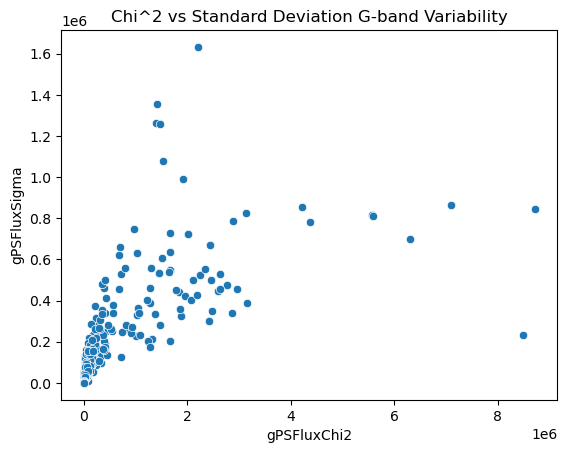

In [93]:
# Chi^2 vs Std Dev g-band 
sns.scatterplot(data=diaobject_all, x='g_gPSFluxChi2', y='g_gPSFluxSigma')
plt.xlabel('gPSFluxChi2'); plt.ylabel('gPSFluxSigma')
plt.title('Chi^2 vs Standard Deviation G-band Variability'); plt.show()

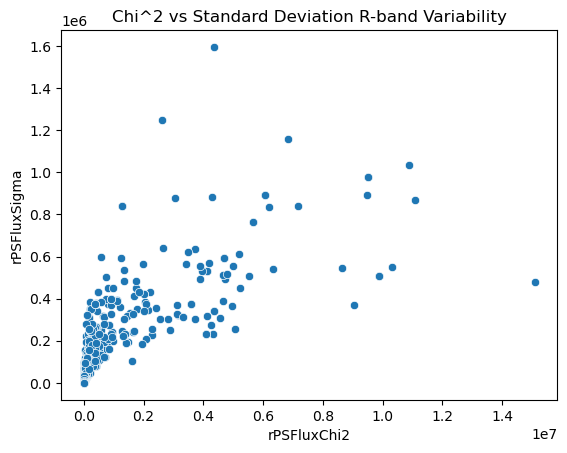

In [94]:
# Chi^2 vs Std Dev r-band 
sns.scatterplot(data=diaobject_all, x='r_rPSFluxChi2', y='r_rPSFluxSigma')
plt.xlabel('rPSFluxChi2'); plt.ylabel('rPSFluxSigma')
plt.title('Chi^2 vs Standard Deviation R-band Variability'); plt.show()

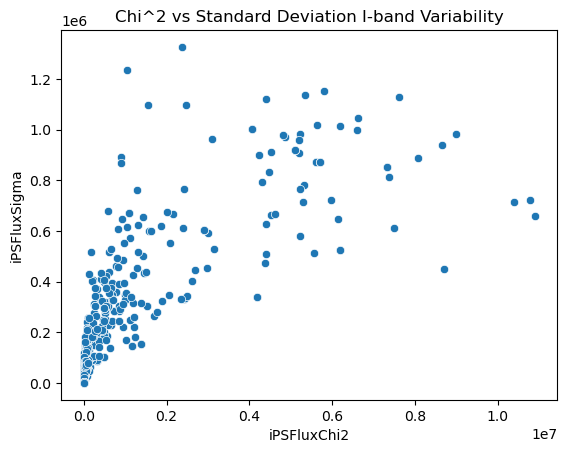

In [95]:
# Chi^2 vs Std Dev i-band 
sns.scatterplot(data=diaobject_all, x='i_iPSFluxChi2', y='i_iPSFluxSigma')
plt.xlabel('iPSFluxChi2'); plt.ylabel('iPSFluxSigma')
plt.title('Chi^2 vs Standard Deviation I-band Variability'); plt.show()

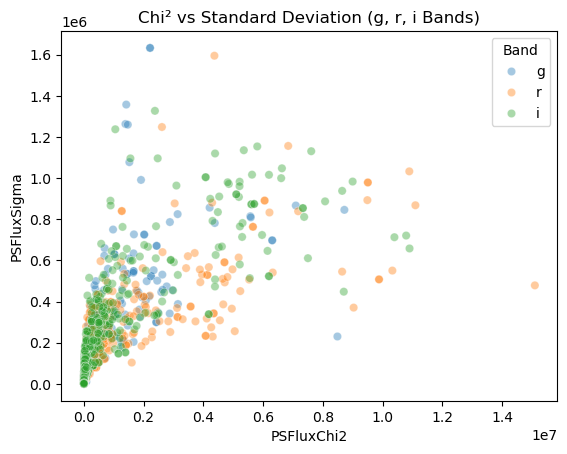

In [96]:
# Chi^2 vs Std Dev Comparison Plot
chi2 = pd.concat([
    diaobject_all['g_gPSFluxChi2'].reset_index(drop=True),
    diaobject_all['r_rPSFluxChi2'].reset_index(drop=True),
    diaobject_all['i_iPSFluxChi2'].reset_index(drop=True)
])

sigma = pd.concat([
    diaobject_all['g_gPSFluxSigma'].reset_index(drop=True),
    diaobject_all['r_rPSFluxSigma'].reset_index(drop=True),
    diaobject_all['i_iPSFluxSigma'].reset_index(drop=True)
])

band = pd.Series(['g'] * len(diaobject_all) + ['r'] * len(diaobject_all) + ['i'] * len(diaobject_all))

# into a singular dataframe
chi_sigma_long = pd.DataFrame({
    'Chi2': chi2.values,
    'Sigma': sigma.values,
    'Band': band.values
})

sns.scatterplot(data=chi_sigma_long, x='Chi2', y='Sigma', hue='Band', alpha=0.4)
plt.title('Chi² vs Standard Deviation (g, r, i Bands)')
plt.xlabel('PSFluxChi2')
plt.ylabel('PSFluxSigma')
plt.legend(title='Band')
plt.show()

2) Stetson J vs Skew (per band): Looks for asymmetric pulses (e.g., RR Lyrae rise/fall pattern)

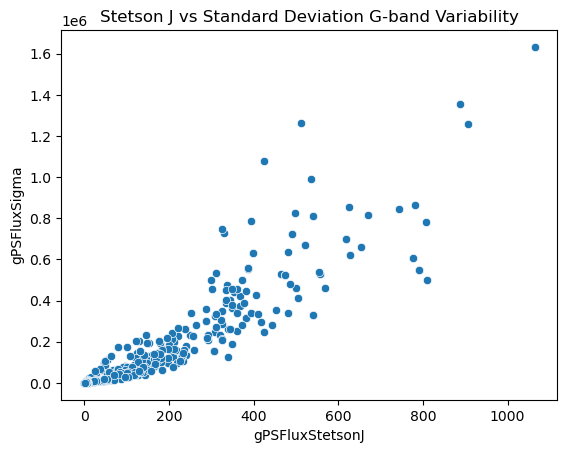

In [97]:
# Stetson J vs Skew g-band
sns.scatterplot(data=diaobject_all, x='g_gPSFluxStetsonJ', y='g_gPSFluxSigma')
plt.xlabel('gPSFluxStetsonJ'); plt.ylabel('gPSFluxSigma')
plt.title('Stetson J vs Standard Deviation G-band Variability'); plt.show()

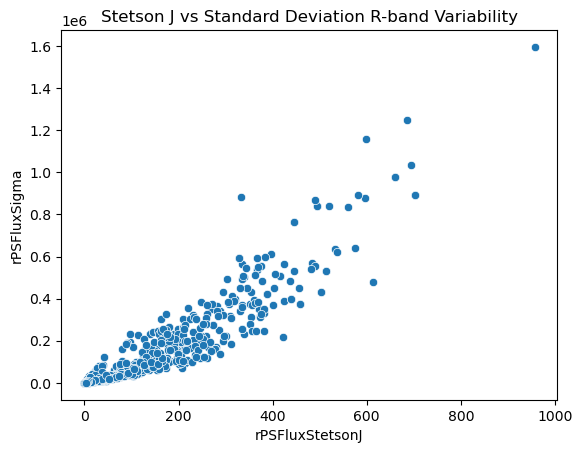

In [98]:
# Stetson J vs Skew r-band
sns.scatterplot(data=diaobject_all, x='r_rPSFluxStetsonJ', y='r_rPSFluxSigma')
plt.xlabel('rPSFluxStetsonJ'); plt.ylabel('rPSFluxSigma')
plt.title('Stetson J vs Standard Deviation R-band Variability'); plt.show()

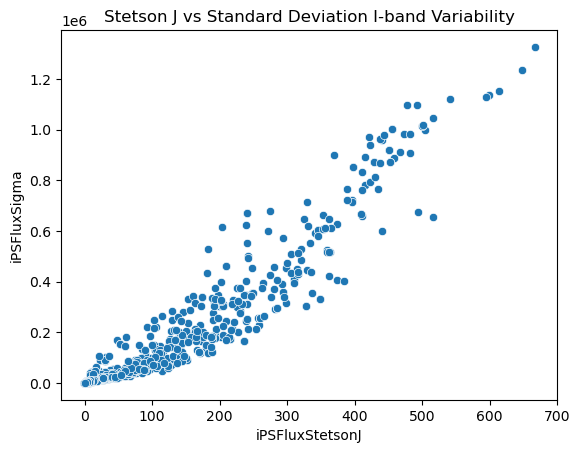

In [99]:
# Stetson J vs Skew i-band
sns.scatterplot(data=diaobject_all, x='i_iPSFluxStetsonJ', y='i_iPSFluxSigma')
plt.xlabel('iPSFluxStetsonJ'); plt.ylabel('iPSFluxSigma')
plt.title('Stetson J vs Standard Deviation I-band Variability'); plt.show()

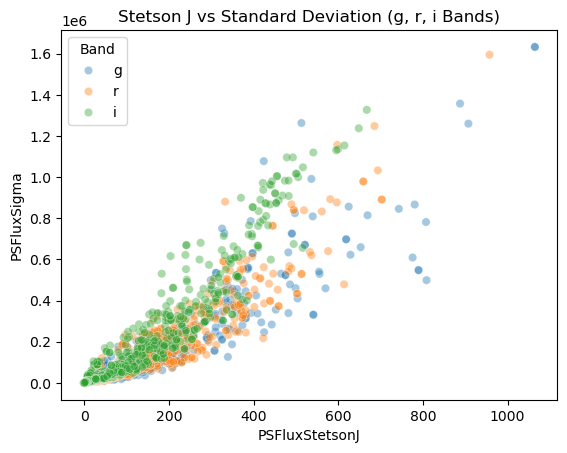

In [100]:
# Stetson J vs Skew Comparison Plot
stetsonj = pd.concat([
    diaobject_all['g_gPSFluxStetsonJ'].reset_index(drop=True),
    diaobject_all['r_rPSFluxStetsonJ'].reset_index(drop=True),
    diaobject_all['i_iPSFluxStetsonJ'].reset_index(drop=True)
])

stetsonj_sigma_long = pd.DataFrame({
    'StetsonJ': stetsonj.values,
    'Sigma': sigma.values,
    'Band': band.values
})

sns.scatterplot(data=stetsonj_sigma_long, x='StetsonJ', y='Sigma', hue='Band', alpha=0.4)
plt.title('Stetson J vs Standard Deviation (g, r, i Bands)')
plt.xlabel('PSFluxStetsonJ')
plt.ylabel('PSFluxSigma')
plt.legend(title='Band')
plt.show()

3) MAD vs Std Dev Histogram(per band): Compares outlier-robust and sensitive metrics

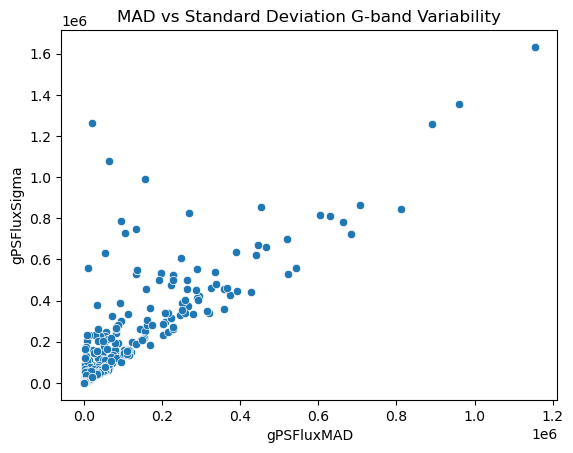

In [101]:
# MAD vs Std Dev Histogram g-band
sns.scatterplot(data=diaobject_all, x='g_gPSFluxMAD', y='g_gPSFluxSigma')
plt.xlabel('gPSFluxMAD'); plt.ylabel('gPSFluxSigma')
plt.title('MAD vs Standard Deviation G-band Variability'); plt.show()

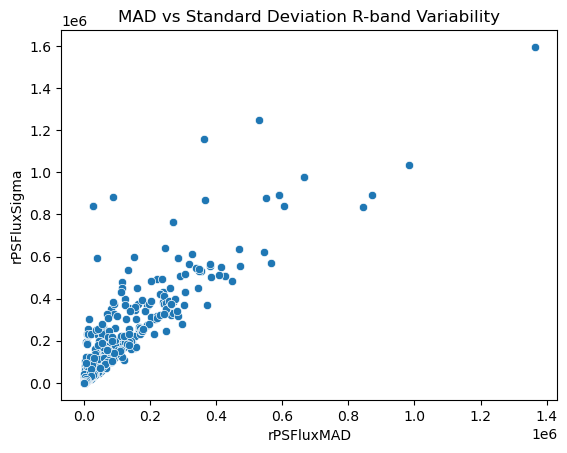

In [102]:
# MAD vs Std Dev Histogram r-band
sns.scatterplot(data=diaobject_all, x='r_rPSFluxMAD', y='r_rPSFluxSigma')
plt.xlabel('rPSFluxMAD'); plt.ylabel('rPSFluxSigma')
plt.title('MAD vs Standard Deviation R-band Variability'); plt.show()

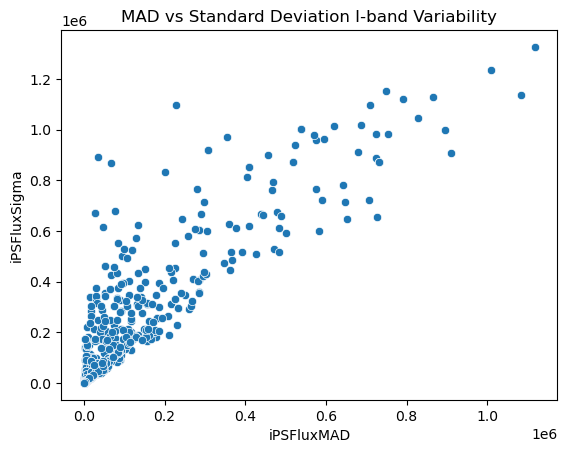

In [103]:
# MAD vs Std Dev Histogram i-band
sns.scatterplot(data=diaobject_all, x='i_iPSFluxMAD', y='i_iPSFluxSigma')
plt.xlabel('iPSFluxMAD'); plt.ylabel('iPSFluxSigma')
plt.title('MAD vs Standard Deviation I-band Variability'); plt.show()

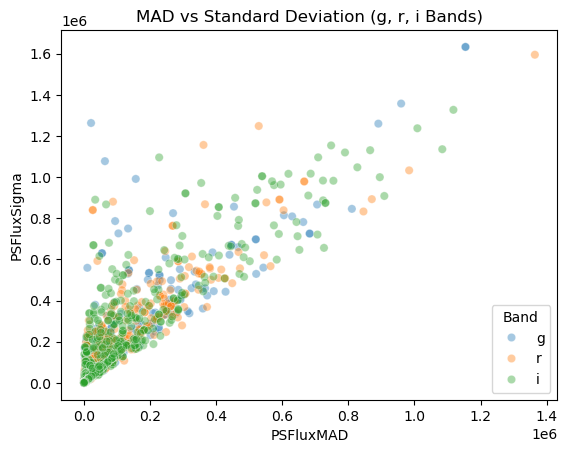

In [104]:
# MAD vs Std Dev Histogram Comparison Plot
mad = pd.concat([
    diaobject_all['g_gPSFluxMAD'].reset_index(drop=True),
    diaobject_all['r_rPSFluxMAD'].reset_index(drop=True),
    diaobject_all['i_iPSFluxMAD'].reset_index(drop=True)
])

mad_sigma_long = pd.DataFrame({
    'MAD': mad.values,
    'Sigma': sigma.values,
    'Band': band.values
})

sns.scatterplot(data=mad_sigma_long, x='MAD', y='Sigma', hue='Band', alpha=0.4)
plt.title('MAD vs Standard Deviation (g, r, i Bands)')
plt.xlabel('PSFluxMAD')
plt.ylabel('PSFluxSigma')
plt.legend(title='Band')
plt.show()

4) Flux Range Histogram (Max - Min)(per band): Finds large-amplitude stars

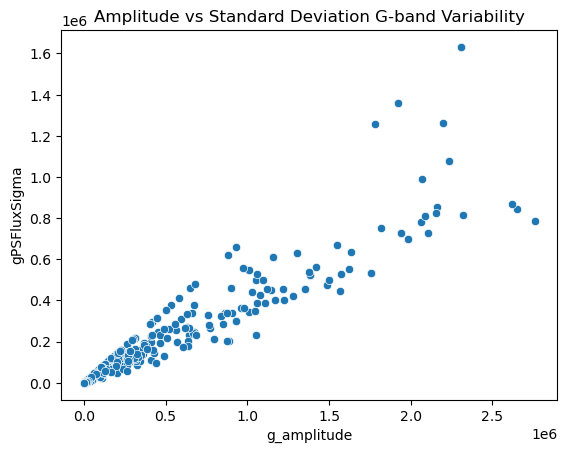

In [105]:
# Flux Range Histogram (Max - Min) g-band
sns.scatterplot(data=diaobject_all, x='g_amplitude', y='g_gPSFluxSigma')
plt.xlabel('g_amplitude'); plt.ylabel('gPSFluxSigma')
plt.title('Amplitude vs Standard Deviation G-band Variability'); plt.show()

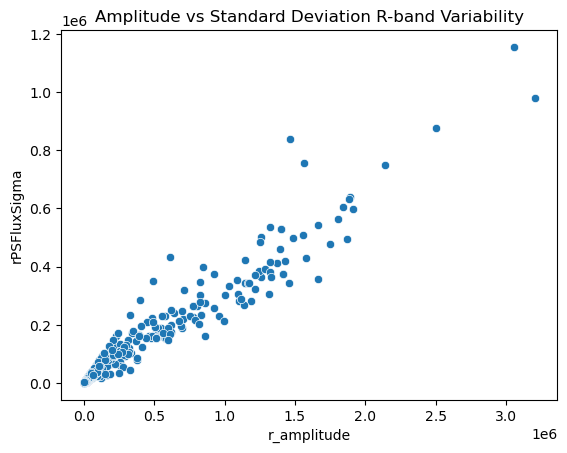

In [56]:
# Flux Range Histogram (Max - Min) r-band
sns.scatterplot(data=diaobject_all, x='r_amplitude', y='r_rPSFluxSigma')
plt.xlabel('r_amplitude'); plt.ylabel('rPSFluxSigma')
plt.title('Amplitude vs Standard Deviation R-band Variability'); plt.show()

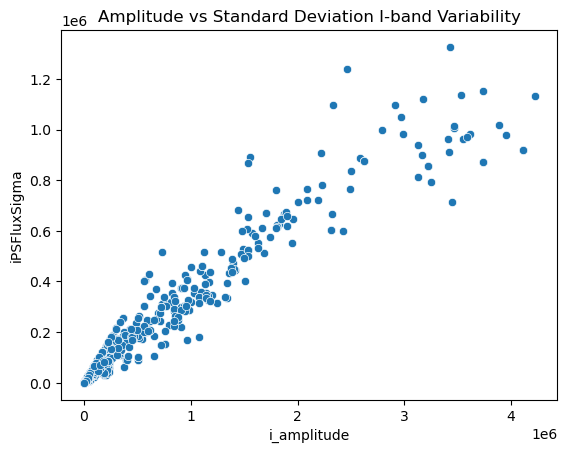

In [106]:
# Flux Range Histogram (Max - Min) i-band
sns.scatterplot(data=diaobject_all, x='i_amplitude', y='i_iPSFluxSigma')
plt.xlabel('i_amplitude'); plt.ylabel('iPSFluxSigma')
plt.title('Amplitude vs Standard Deviation I-band Variability'); plt.show()

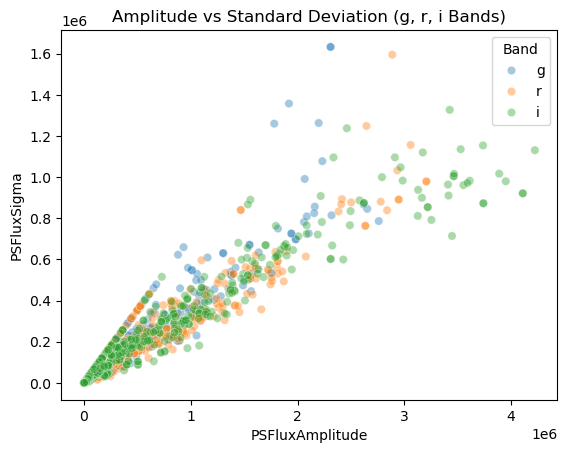

In [107]:
# Flux Range Histogram (Max - Min) Comparison Plot 
amplitude = pd.concat([
    diaobject_all['g_amplitude'].reset_index(drop=True),
    diaobject_all['r_amplitude'].reset_index(drop=True),
    diaobject_all['i_amplitude'].reset_index(drop=True)
])

amplitude_sigma_long = pd.DataFrame({
    'Amplitude': amplitude.values,
    'Sigma': sigma.values,
    'Band': band.values
})

sns.scatterplot(data=amplitude_sigma_long, x='Amplitude', y='Sigma', hue='Band', alpha=0.4)
plt.title('Amplitude vs Standard Deviation (g, r, i Bands)')
plt.xlabel('PSFluxAmplitude')
plt.ylabel('PSFluxSigma')
plt.legend(title='Band')
plt.show()

5) Chi² vs N Data Points(per band): Validates metric reliability

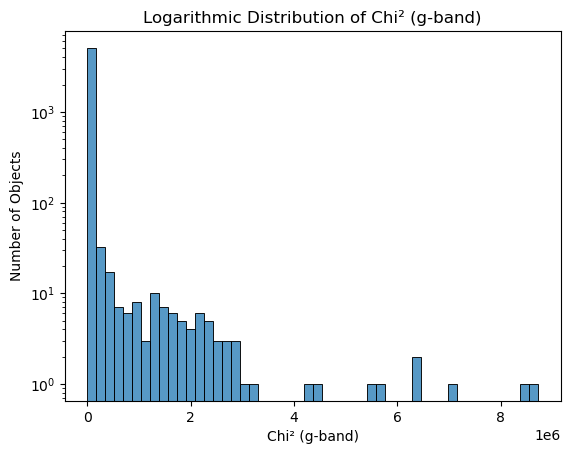

In [108]:
#  Chi² vs N Data Points g-band
sns.histplot(diaobject_all['g_gPSFluxChi2'], bins=50, kde=False)

plt.xlabel('Chi² (g-band)')
plt.ylabel('Number of Objects')
plt.title('Logarithmic Distribution of Chi² (g-band)')
plt.yscale('log')  # counts are skewed
plt.show()

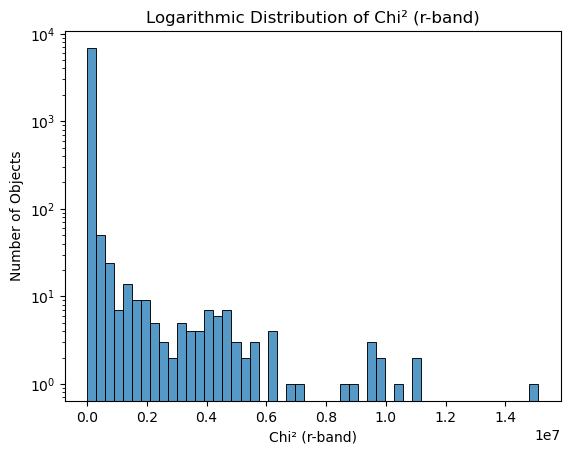

In [109]:
#  Chi² vs N Data Points r-band
sns.histplot(diaobject_all['r_rPSFluxChi2'], bins=50, kde=False)

plt.xlabel('Chi² (r-band)')
plt.ylabel('Number of Objects')
plt.title('Logarithmic Distribution of Chi² (r-band)')
plt.yscale('log')
plt.show()

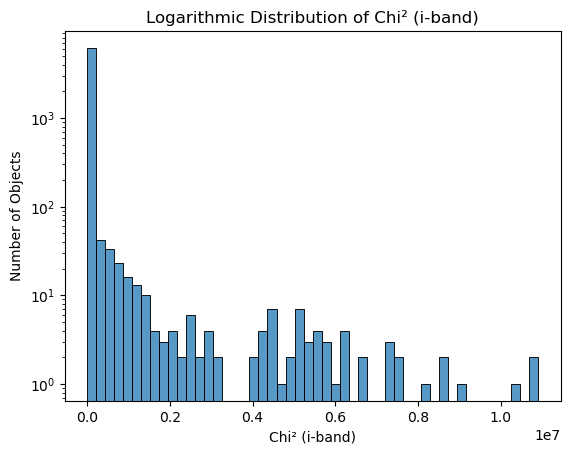

In [110]:
#  Chi² vs N Data Points i-band
sns.histplot(diaobject_all['i_iPSFluxChi2'], bins=50, kde=False)

plt.xlabel('Chi² (i-band)')
plt.ylabel('Number of Objects')
plt.title('Logarithmic Distribution of Chi² (i-band)')
plt.yscale('log')
plt.show()

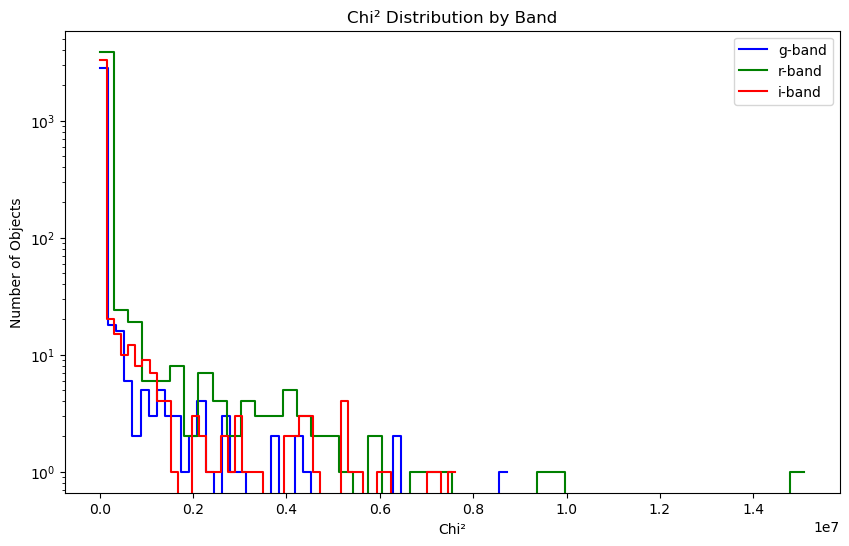

In [83]:
#  Chi² vs N Data Points Comparison Plot 
plt.figure(figsize=(10, 6))
sns.histplot(diaobject_all['g_gPSFluxChi2'], bins=50, color='blue', label='g-band', stat='count', element='step', fill=False)
sns.histplot(diaobject_all['r_rPSFluxChi2'], bins=50, color='green', label='r-band', stat='count', element='step', fill=False)
sns.histplot(diaobject_all['i_iPSFluxChi2'], bins=50, color='red', label='i-band', stat='count', element='step', fill=False)

plt.xlabel('Chi²')
plt.ylabel('Number of Objects')
plt.title('Chi² Distribution by Band')
plt.legend()
plt.yscale('log')
plt.show()

6) Skew vs Std Dev (per band): Differentiates noise from true variability

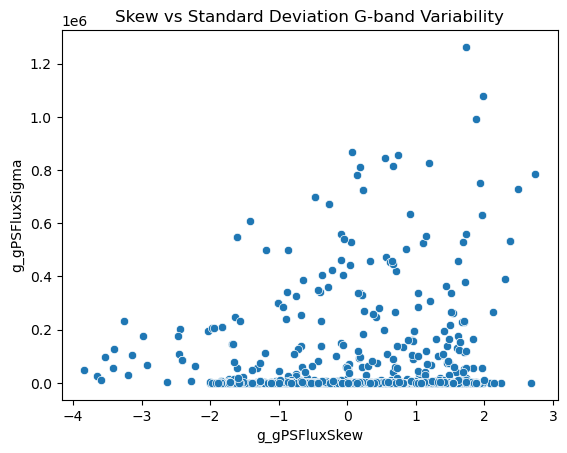

In [111]:
# Skew vs Std Dev g-band
sns.scatterplot(data=diaobject_all, x='g_gPSFluxSkew', y='g_gPSFluxSigma')
plt.xlabel('g_gPSFluxSkew'); plt.ylabel('g_gPSFluxSigma')
plt.title('Skew vs Standard Deviation G-band Variability'); plt.show()

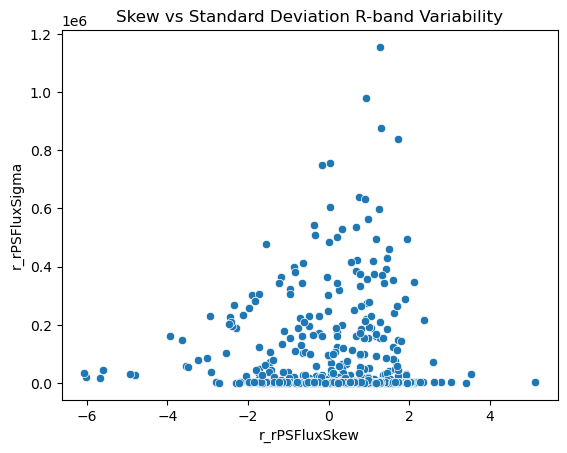

In [64]:
# Skew vs Std Dev r-band
sns.scatterplot(data=diaobject_all, x='r_rPSFluxSkew', y='r_rPSFluxSigma')
plt.xlabel('r_rPSFluxSkew'); plt.ylabel('r_rPSFluxSigma')
plt.title('Skew vs Standard Deviation R-band Variability'); plt.show()

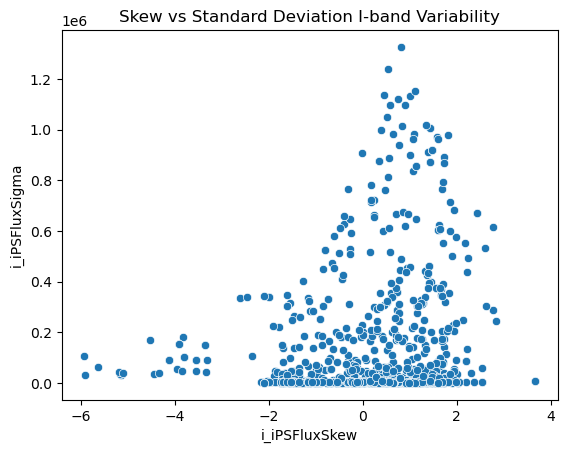

In [112]:
# Skew vs Std Dev i-band
sns.scatterplot(data=diaobject_all, x='i_iPSFluxSkew', y='i_iPSFluxSigma')
plt.xlabel('i_iPSFluxSkew'); plt.ylabel('i_iPSFluxSigma')
plt.title('Skew vs Standard Deviation I-band Variability'); plt.show()

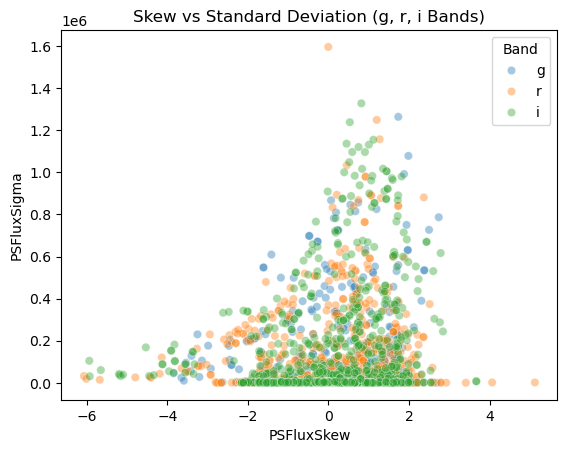

In [113]:
# Skew vs Std Dev Comparison Plot
skew = pd.concat([
    diaobject_all['g_gPSFluxSkew'].reset_index(drop=True),
    diaobject_all['r_rPSFluxSkew'].reset_index(drop=True),
    diaobject_all['i_iPSFluxSkew'].reset_index(drop=True)
])

# into a singular dataframe
skew_sigma_long = pd.DataFrame({
    'Skew': skew.values,
    'Sigma': sigma.values,
    'Band': band.values
})

sns.scatterplot(data=skew_sigma_long, x='Skew', y='Sigma', hue='Band', alpha=0.4)
plt.title('Skew vs Standard Deviation (g, r, i Bands)')
plt.xlabel('PSFluxSkew')
plt.ylabel('PSFluxSigma')
plt.legend(title='Band')
plt.show()

7) Stetson J vs Flux Range(per band): Flags high-priority candidates

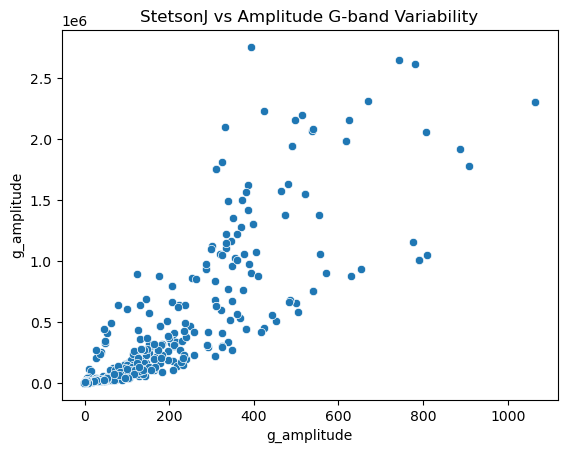

In [114]:
# Stetson J vs Flux Range g-band
sns.scatterplot(data=diaobject_all, x='g_gPSFluxStetsonJ', y='g_amplitude')
plt.xlabel('g_amplitude'); plt.ylabel('g_amplitude')
plt.title('StetsonJ vs Amplitude G-band Variability'); plt.show()

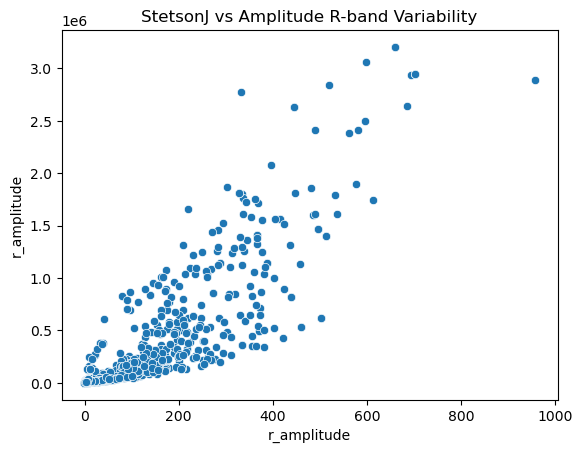

In [115]:
# Stetson J vs Flux Range r-band
sns.scatterplot(data=diaobject_all, x='r_rPSFluxStetsonJ', y='r_amplitude')
plt.xlabel('r_amplitude'); plt.ylabel('r_amplitude')
plt.title('StetsonJ vs Amplitude R-band Variability'); plt.show()

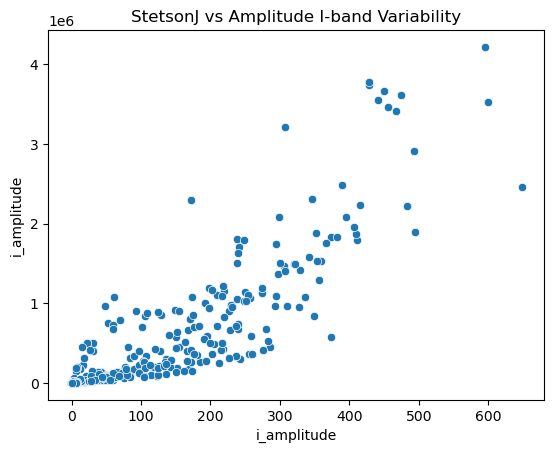

In [76]:
# Stetson J vs Flux Range i-band
sns.scatterplot(data=diaobject_all, x='i_iPSFluxStetsonJ', y='i_amplitude')
plt.xlabel('i_amplitude'); plt.ylabel('i_amplitude')
plt.title('StetsonJ vs Amplitude I-band Variability'); plt.show()

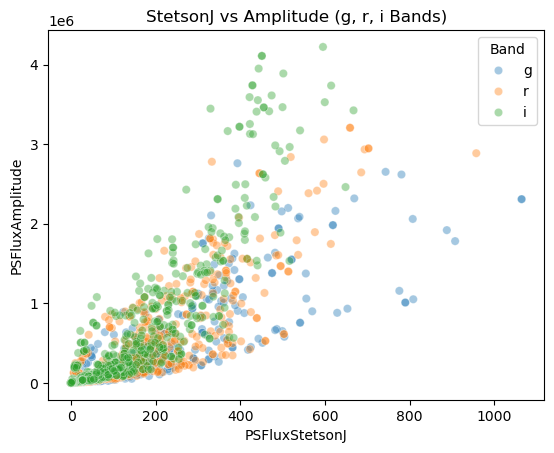

In [116]:
# Stetson J vs Flux Range Comparison Plot 
stetsonj_amplitude_long = pd.DataFrame({
    'StetsonJ': stetsonj.values,
    'Amplitude': amplitude.values,
    'Band': band.values
})

sns.scatterplot(data=stetsonj_amplitude_long, x='StetsonJ', y='Amplitude', hue='Band', alpha=0.4)
plt.title('StetsonJ vs Amplitude (g, r, i Bands)')
plt.xlabel('PSFluxStetsonJ')
plt.ylabel('PSFluxAmplitude')
plt.legend(title='Band')
plt.show()

## Summary of Color and Flux Variability Analysis

This section focuses on the relationship between photometric band variability (via `PSFluxSigma`) and color indices (g–r, r–i) to distinguish different types of pulsating stars in the Rubin DP0.2 dataset.

### Key Findings

- **Cross-band PSFluxSigma comparisons** (g vs r, g vs i, r vs i):
  - **RR Lyrae** exhibit stronger variability in the **g-band**, appearing **above the diagonal** in g vs r/i plots.
  - **Cepheids** and **Miras** often show **greater variability in redder bands** (r or i), appearing **below the diagonal**.
  - **r vs i** comparisons help distinguish **Miras** (higher i-variability) from **Cepheids** (higher r-variability).

- **Color vs Variability**:
  - **RR Lyrae** have **blue colors** (`g - r < 0`, `r - i < 0`) and **high g-band variability**
  - **Miras** are **very red** (`r - i > 0.5`) and show strong variability in **i-band**.
  - **Cepheids** lie in **intermediate color and variability ranges**
  - These trends allow for **rough separation** of variable star types based on color–flux scatter plots.

- **Flux Variability Distributions**:
  - Histograms of `PSFluxSigma` across g, r, and i bands show a **majority of low-variability stars**, with a **long right tail** of highly variable sources.
  - This supports using the **upper tail** as a way to define thresholds for what counts as “variable”.

- **Outliers and Transitions**:
  - A few **red, high-variability objects** fall between clear Mira/Cepheid boundaries, which may represent **misclassified or transitional objects**. This is worth flagging for further analysis.

---

### Summary of Color–Flux Trends

| Variable Type | Color Index Traits        | Variability Pattern         | Band Peak  |
|---------------|---------------------------|------------------------------|------------|
| **RR Lyrae**  | Blue (`g - r < 0`)         | Strong variability in g      | **g-band** |
| **Cepheids**  | Intermediate colors        | Moderate r > i variability   | **r-band** |
| **Miras**     | Very red (`r - i > 0.5`)   | High amplitude in i          | **i-band** |

---

### Results & Interpretation

- **RR Lyrae**: Short-period stars with symmetric, periodic light curves. Dominant variation in **blue** wavelengths (g-band).
- **Cepheids**: Intermediate-period stars useful as distance indicators. Strongest in **r-band**.
- **Miras**: Long-period, cool red giants with large amplitude changes. Variation peaks in **i-band**, typically redder in color.